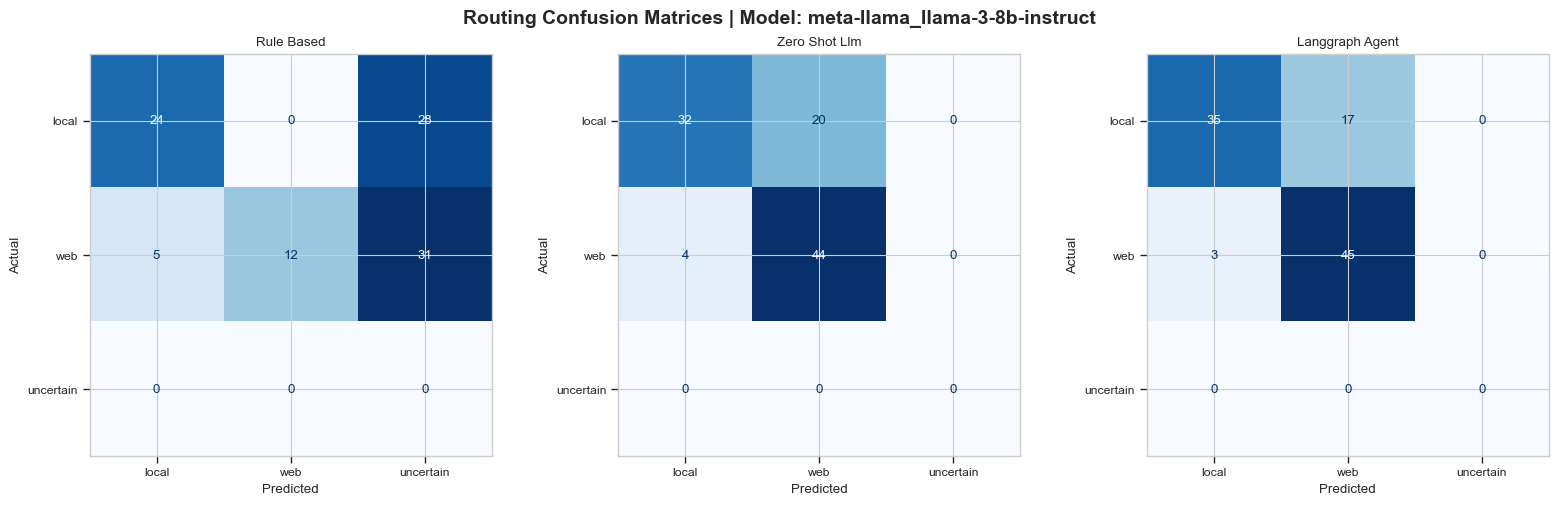

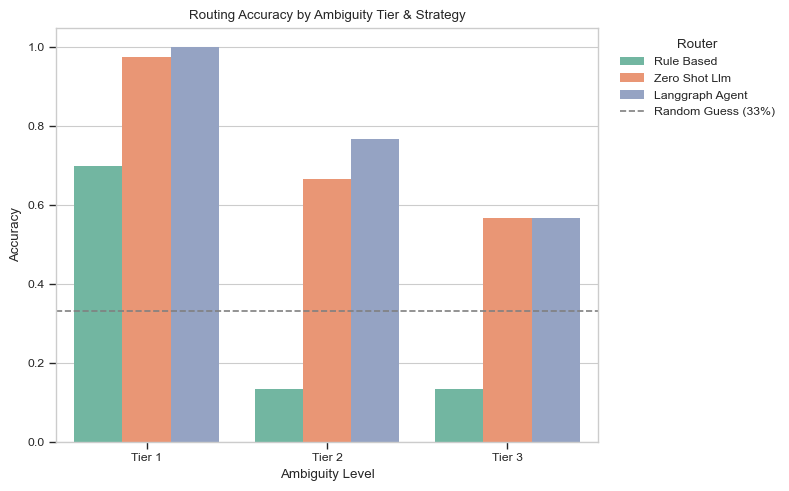

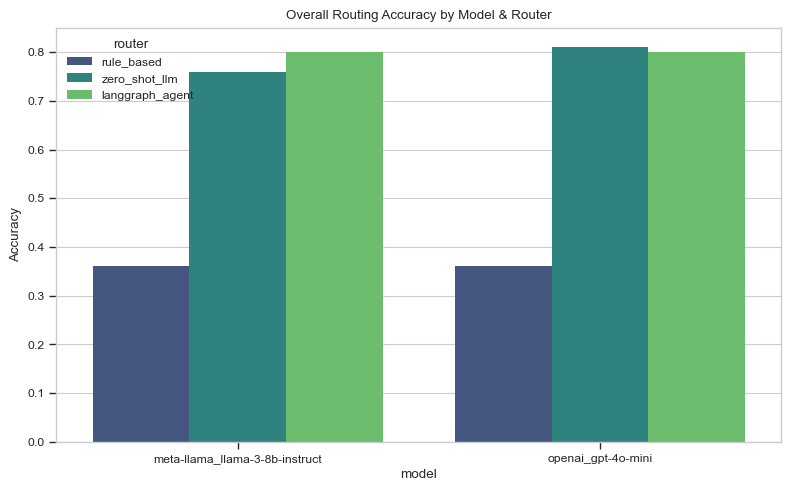

📝 Exporting Top Failure Cases for Report...
✅ Saved to ../data/results/qualitative_failures.csv

Sample Failures:
[rule_based] Q7 (Tier 1)
  GT: web | Pred: local
  Prompt: "What has Adobe announced in the past month regarding new product launches?"

[rule_based] Q8 (Tier 1)
  GT: web | Pred: uncertain
  Prompt: "Which Wall Street analysts have upgraded or downgraded Airbnb stock in the last 30 days?"

[rule_based] Q10 (Tier 1)
  GT: web | Pred: uncertain
  Prompt: "What new credit card product did American Express launch this quarter?"



In [1]:
# Cell 1 [Markdown]

# # 📉 Visualization & Qualitative Analysis

# Generates publication-ready plots: confusion matrices, accuracy vs tier trends, 

# model comparisons, and structured failure case analysis.
 
# Cell 2 [Code]

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from pathlib import Path

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import json
 
plt.style.use('seaborn-v0_8-whitegrid')

sns.set_context("paper")

RESULTS_DIR = Path("../data/results")
 
# Load results

csv_path = list(RESULTS_DIR.glob("routing_results_*.csv"))[0]

df = pd.read_csv(csv_path)

model_name = csv_path.stem.replace("routing_results_", "")

routers = [c for c in df.columns if c.endswith("_tool") and c != "ground_truth"]
 
labels = ["local", "web", "uncertain"]
 
# Cell 3 [Code]

# 1. Confusion Matrices for All Routers

fig, axes = plt.subplots(1, len(routers), figsize=(16, 5))

for ax, router in zip(axes, routers):

    cm = confusion_matrix(df["ground_truth"], df[router], labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    disp.plot(cmap="Blues", ax=ax, colorbar=False)

    ax.set_title(f"{router.replace('_tool', '').replace('_', ' ').title()}")

    ax.set_xlabel("Predicted")

    ax.set_ylabel("Actual")

plt.suptitle(f"Routing Confusion Matrices | Model: {model_name}", fontsize=14, fontweight="bold")

plt.tight_layout()

plt.savefig("../data/results/confusion_matrices.png", dpi=300)

plt.show()
 
# Cell 4 [Code]

# 2. Accuracy vs Ambiguity Tier

tier_accuracies = []

for tier in [1, 2, 3]:

    mask = df["ambiguity_tier"] == tier

    for router in routers:

        acc = (df[mask][router] == df[mask]["ground_truth"]).mean()

        tier_accuracies.append({

            "router": router.replace("_tool", "").replace("_", " ").title(),

            "tier": f"Tier {tier}",

            "accuracy": acc

        })
 
acc_df = pd.DataFrame(tier_accuracies)

plt.figure(figsize=(8, 5))

sns.barplot(data=acc_df, x="tier", y="accuracy", hue="router", palette="Set2")

plt.axhline(y=0.33, color="gray", linestyle="--", label="Random Guess (33%)")

plt.title("Routing Accuracy by Ambiguity Tier & Strategy")

plt.ylabel("Accuracy")

plt.xlabel("Ambiguity Level")

plt.legend(title="Router", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

plt.savefig("../data/results/accuracy_vs_tier.png", dpi=300, bbox_inches="tight")

plt.show()
 
# Cell 5 [Code]

# 3. Model Comparison (If multiple models were run)

all_csvs = list(RESULTS_DIR.glob("routing_results_*.csv"))

if len(all_csvs) > 1:

    model_acc = []

    for csv_p in all_csvs:

        temp_df = pd.read_csv(csv_p)

        m_name = csv_p.stem.replace("routing_results_", "")

        for router in [c for c in temp_df.columns if c.endswith("_tool")]:

            acc = (temp_df[router] == temp_df["ground_truth"]).mean()

            model_acc.append({"model": m_name, "router": router.replace("_tool", ""), "accuracy": acc})

    comp_df = pd.DataFrame(model_acc)

    plt.figure(figsize=(8, 5))

    sns.barplot(data=comp_df, x="model", y="accuracy", hue="router", palette="viridis")

    plt.title("Overall Routing Accuracy by Model & Router")

    plt.ylabel("Accuracy")

    plt.tight_layout()

    plt.savefig("../data/results/model_comparison.png", dpi=300)

    plt.show()
 
# Cell 6 [Code]

# 4. Qualitative Failure Case Export

print("📝 Exporting Top Failure Cases for Report...")

failures = []

for router in routers:

    errs = df[df[router] != df["ground_truth"]]

    for _, row in errs.head(3).iterrows():

        failures.append({

            "router": router.replace("_tool", ""),

            "query_id": row["query_id"],

            "prompt": row["prompt"],

            "ground_truth": row["ground_truth"],

            "predicted": row[router],

            "ambiguity_tier": row["ambiguity_tier"]

        })
 
pd.DataFrame(failures).to_csv("../data/results/qualitative_failures.csv", index=False)

print("✅ Saved to ../data/results/qualitative_failures.csv")

print("\nSample Failures:")

for f in failures[:3]:

    print(f"[{f['router']}] Q{f['query_id']} (Tier {f['ambiguity_tier']})")

    print(f"  GT: {f['ground_truth']} | Pred: {f['predicted']}")

    print(f"  Prompt: \"{f['prompt']}\"\n")
 